<a href="https://colab.research.google.com/github/Tomal162/B8A2-Gamer-Zone/blob/main/Codveda_Tasks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Level 1 Task 1 : Data Preprocessing for Machine Learning

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
print(os.listdir('/content/drive/MyDrive/Codveda'))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['1) iris.csv', '4) house Prediction Data Set.csv', '3) Sentiment dataset.csv', '2) Stock Prices Data Set.csv', 'Churn Prdiction Data']


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split


df = pd.read_csv('/content/drive/MyDrive/Codveda/1) iris.csv')

print("Dataset loaded successfully! Shape:", df.shape)
df.head()

Dataset loaded successfully! Shape: (150, 5)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [ ]:
print("Missing values in each column:")
print(df.isnull().sum())


print("\nNo missing values.")

Missing values in each column:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

No missing values.


In [ ]:
print("Unique species before encoding:", df['species'].unique())

le = LabelEncoder()
df['species_encoded'] = le.fit_transform(df['species'])
print("\nAfter label encoding:")
print(df[['species', 'species_encoded']].head())
print("Encoding has completed.")

Unique species before encoding: ['setosa' 'versicolor' 'virginica']

After label encoding:
  species  species_encoded
0  setosa                0
1  setosa                0
2  setosa                0
3  setosa                0
4  setosa                0
Encoding has completed.


In [ ]:
feature_cols = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

scaler = StandardScaler()
df[feature_cols] = scaler.fit_transform(df[feature_cols])

print("Features normalized (mean ≈ 0, std ≈ 1). Here's a sample:")
df[feature_cols].head()

Features normalized (mean ≈ 0, std ≈ 1). Here's a sample:


,sepal_length,sepal_width,petal_length,petal_width
0,-0.900681,1.032057,-1.341272,-1.312977
1,-1.143017,-0.124958,-1.341272,-1.312977
2,-1.385353,0.337848,-1.398138,-1.312977
3,-1.506521,0.106445,-1.284407,-1.312977
4,-1.021849,1.263460,-1.341272,-1.312977


In [ ]:
X = df[feature_cols]
y = df['species_encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Split complete!")
print("Training set shape:", X_train.shape)
print("Testing set shape :", X_test.shape)

Split complete!
Training set shape: (120, 4)
Testing set shape : (30, 4)


In [ ]:
print("PREPROCESSED DATA READY FOR MACHINE LEARNING")
print(df.head())

df.to_csv('/content/drive/MyDrive/iris_preprocessed.csv', index=False)
print("\nSaved cleaned version as iris_preprocessed.csv")

PREPROCESSED DATA READY FOR MACHINE LEARNING
   sepal_length  sepal_width  petal_length  petal_width species  \
0     -0.900681     1.032057     -1.341272    -1.312977  setosa   
1     -1.143017    -0.124958     -1.341272    -1.312977  setosa   
2     -1.385353     0.337848     -1.398138    -1.312977  setosa   
3     -1.506521     0.106445     -1.284407    -1.312977  setosa   
4     -1.021849     1.263460     -1.341272    -1.312977  setosa   

   species_encoded  
0                0  
1                0  
2                0  
3                0  
4                0  

Saved cleaned version as iris_preprocessed.csv


In [ ]:
# Level 1 Task 2 : Build a Simple Linear Regression Model

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt

print("Libraries imported!")

Libraries imported!


In [ ]:
import pandas as pd

file_path = '/content/drive/MyDrive/Codveda/4) house Prediction Data Set.csv'

df = pd.read_csv(file_path,
                 header=None,
                 sep='\s+')

df.columns = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE',
              'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']

print("Shape of dataset:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nColumn names:", df.columns.tolist())

<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_4920/2208690658.py:7: SyntaxWarning: invalid escape sequence '\s'
  sep='\s+')


Shape of dataset: (506, 14)

First 5 rows:
      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296.0   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242.0   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242.0   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222.0   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222.0   

   PTRATIO       B  LSTAT  MEDV  
0     15.3  396.90   4.98  24.0  
1     17.8  396.90   9.14  21.6  
2     17.8  392.83   4.03  34.7  
3     18.7  394.63   2.94  33.4  
4     18.7  396.90   5.33  36.2  

Column names: ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']


In [ ]:

X = df[['RM']]
y = df['MEDV']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training data: {X_train.shape[0]} rows")
print(f"Testing data: {X_test.shape[0]} rows")

Training data: 404 rows
Testing data: 102 rows


In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [ ]:
print("Coefficient (slope) for RM:", round(model.coef_[0], 4))
print("Intercept:", round(model.intercept_, 4))

Coefficient (slope) for RM: 9.3483
Intercept: -36.2463


In [ ]:
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f"R-squared (R²): {r2:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")

R-squared (R²): 0.3708
Mean Squared Error (MSE): 46.1448


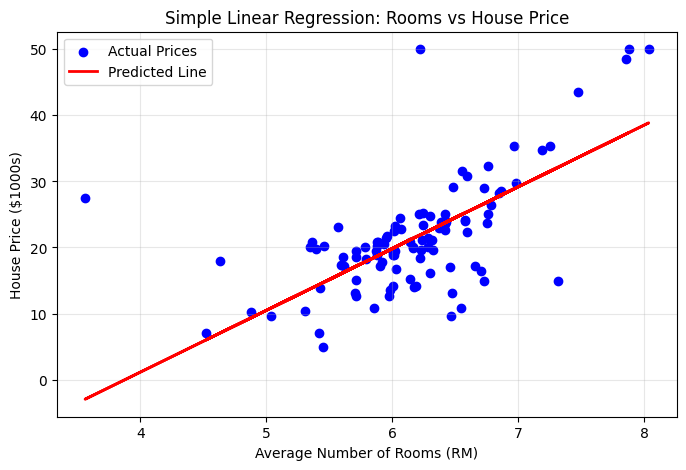

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(X_test, y_test, color='blue', label='Actual Prices')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Predicted Line')
plt.title('Simple Linear Regression: Rooms vs House Price')
plt.xlabel('Average Number of Rooms (RM)')
plt.ylabel('House Price ($1000s)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# Level 1 Task 3 : Implement K-Nearest Neighbors (KNN) Classifier

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

median_price = df['MEDV'].median()
df['Price_Category'] = np.where(df['MEDV'] > median_price, 'High', 'Low')

print("Target created!")
print(df['Price_Category'].value_counts())
print("\nFirst 5 rows of new column:")
print(df[['MEDV', 'Price_Category']].head())

Target created!
Price_Category
Low     256
High    250
Name: count, dtype: int64

First 5 rows of new column:
   MEDV Price_Category
0  24.0           High
1  21.6           High
2  34.7           High
3  33.4           High
4  36.2           High


In [ ]:
X = df.drop(['MEDV', 'Price_Category'], axis=1)
y = df['Price_Category']

print(f"Features shape: {X.shape}")

Features shape: (506, 13)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data split and scaled!")
print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

Data split and scaled!
Training samples: 404
Testing samples: 102


In [ ]:
k_values = [3, 5, 7, 9]
results = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    results.append((k, acc))

    print(f"\nK = {k}")
    print(f"Accuracy: {acc:.4f}")
    print("Classification Report:")
    print(classification_report(y_test, y_pred))

print("Summary of different K values")
for k, acc in results:
    print(f"K = {k:2d}  →  Accuracy = {acc:.4f}")


K = 3
Accuracy: 0.8627
Classification Report:
              precision    recall  f1-score   support

        High       0.89      0.82      0.85        50
         Low       0.84      0.90      0.87        52

    accuracy                           0.86       102
   macro avg       0.87      0.86      0.86       102
weighted avg       0.86      0.86      0.86       102


K = 5
Accuracy: 0.8431
Classification Report:
              precision    recall  f1-score   support

        High       0.87      0.80      0.83        50
         Low       0.82      0.88      0.85        52

    accuracy                           0.84       102
   macro avg       0.85      0.84      0.84       102
weighted avg       0.85      0.84      0.84       102


K = 7
Accuracy: 0.8627
Classification Report:
              precision    recall  f1-score   support

        High       0.93      0.78      0.85        50
         Low       0.82      0.94      0.88        52

    accuracy                           0.

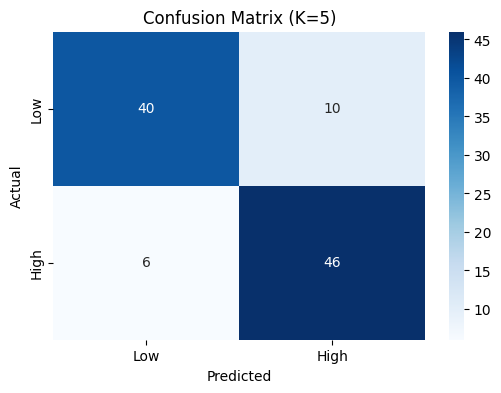

Final Model Performance (K = 5 )
Accuracy : 0.8431372549019608

Classification Report:
              precision    recall  f1-score   support

        High       0.87      0.80      0.83        50
         Low       0.82      0.88      0.85        52

    accuracy                           0.84       102
   macro avg       0.85      0.84      0.84       102
weighted avg       0.85      0.84      0.84       102



In [ ]:
best_k = 5
knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_train_scaled, y_train)
y_pred_final = knn_final.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low', 'High'],
            yticklabels=['Low', 'High'])
plt.title(f'Confusion Matrix (K={best_k})')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print("Final Model Performance (K =", best_k, ")")
print("Accuracy :", accuracy_score(y_test, y_pred_final))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_final))

In [ ]:
# Level 2 Task 1 : Logistic Regression for Binary Classification

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

file_path = '/content/drive/MyDrive/Codveda/Churn Prdiction Data/churn-bigml-80.csv'

df = pd.read_csv(file_path)

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nChurn distribution:")
print(df['Churn'].value_counts())

Dataset shape: (2666, 20)

First 5 rows:
  State  Account length  Area code International plan Voice mail plan  \
0    KS             128        415                 No             Yes   
1    OH             107        415                 No             Yes   
2    NJ             137        415                 No              No   
3    OH              84        408                Yes              No   
4    OK              75        415                Yes              No   

   Number vmail messages  Total day minutes  Total day calls  \
0                     25              265.1              110   
1                     26              161.6              123   
2                      0              243.4              114   
3                      0              299.4               71   
4                      0              166.7              113   

   Total day charge  Total eve minutes  Total eve calls  Total eve charge  \
0             45.07              197.4               99   

In [ ]:
df.columns = [col.strip() for col in df.columns]

df['International plan'] = df['International plan'].map({'Yes': 1, 'No': 0})
df['Voice mail plan']   = df['Voice mail plan'].map({'Yes': 1, 'No': 0})

df['Churn'] = df['Churn'].map({False: 0, True: 1, 'False': 0, 'True': 1})

df = pd.get_dummies(df, columns=['State'], prefix='State', drop_first=True)

print("Preprocessing done!")
print("Shape after encoding:", df.shape)
print("Any missing values?", df.isnull().sum().sum())
print("\nChurn distribution (0 = stay, 1 = churn):")
print(df['Churn'].value_counts(normalize=True))

Preprocessing done!
Shape after encoding: (2666, 69)
Any missing values? 0

Churn distribution (0 = stay, 1 = churn):
Churn
0    0.854464
1    0.145536
Name: proportion, dtype: float64


In [ ]:
X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

Training samples: 2132
Testing samples: 534


In [ ]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

print("Logistic Regression model trained!")

Logistic Regression model trained!


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0],
    'Odds Ratio': np.exp(model.coef_[0])
}).sort_values(by='Odds Ratio', ascending=False)

print("Top 10 features that increase churn probability the most:")
print(coefficients.head(10))

Top 10 features that increase churn probability the most:
               Feature  Coefficient  Odds Ratio
2   International plan     2.417598   11.218877
60            State_TX     1.491305    4.442888
48            State_NJ     0.861309    2.366255
39            State_MI     0.837276    2.310066
57            State_SC     0.781315    2.184342
43            State_MT     0.770152    2.160095
42            State_MS     0.761946    2.142442
38            State_ME     0.734982    2.085445
40            State_MN     0.674984    1.964001
64            State_WA     0.637622    1.891976


In [ ]:
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Stay (0)', 'Churn (1)']))

Accuracy : 0.8427
Precision: 0.4211
Recall   : 0.2051
F1-score : 0.2759

Classification Report:
              precision    recall  f1-score   support

    Stay (0)       0.88      0.95      0.91       456
   Churn (1)       0.42      0.21      0.28        78

    accuracy                           0.84       534
   macro avg       0.65      0.58      0.59       534
weighted avg       0.81      0.84      0.82       534



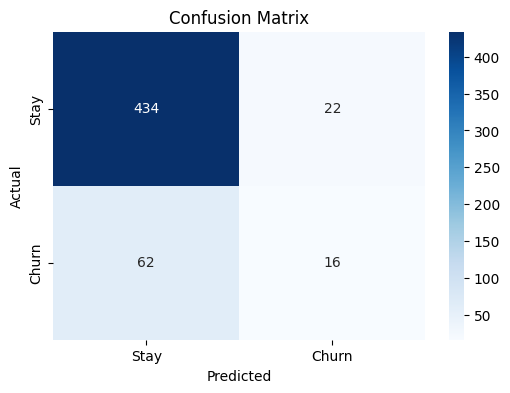

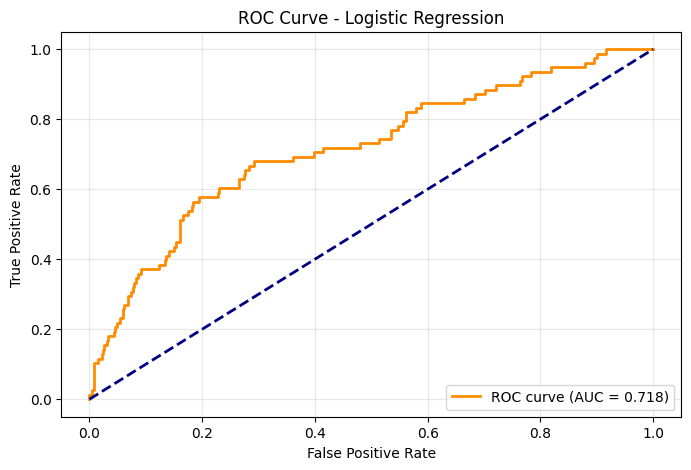

In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stay', 'Churn'],
            yticklabels=['Stay', 'Churn'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# Level 2 Task 2 : Decision Trees for Classification

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

file_path = '/content/drive/MyDrive/Codveda/1) iris.csv'

df = pd.read_csv(file_path, header=0)


print("Dataset shape:", df.shape)
print("\nColumn names:", df.columns.tolist())
print("\nFirst 5 rows:")
print(df.head())
print("\nSpecies distribution:")
print(df['species'].value_counts())

Dataset shape: (150, 5)

Column names: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']

First 5 rows:
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

Species distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


In [ ]:
X = df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']]
y = df['species']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

Training samples: 120
Testing samples: 30


In [ ]:
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)

y_pred_train = tree.predict(X_train)
y_pred_test = tree.predict(X_test)

print("Default (Unpruned) Tree Performance:")
print(f"Train Accuracy: {accuracy_score(y_train, y_pred_train):.4f}")
print(f"Test Accuracy : {accuracy_score(y_test, y_pred_test):.4f}")
print(f"Test F1-score (weighted): {f1_score(y_test, y_pred_test, average='weighted'):.4f}")

Default (Unpruned) Tree Performance:
Train Accuracy: 1.0000
Test Accuracy : 0.9333
Test F1-score (weighted): 0.9333


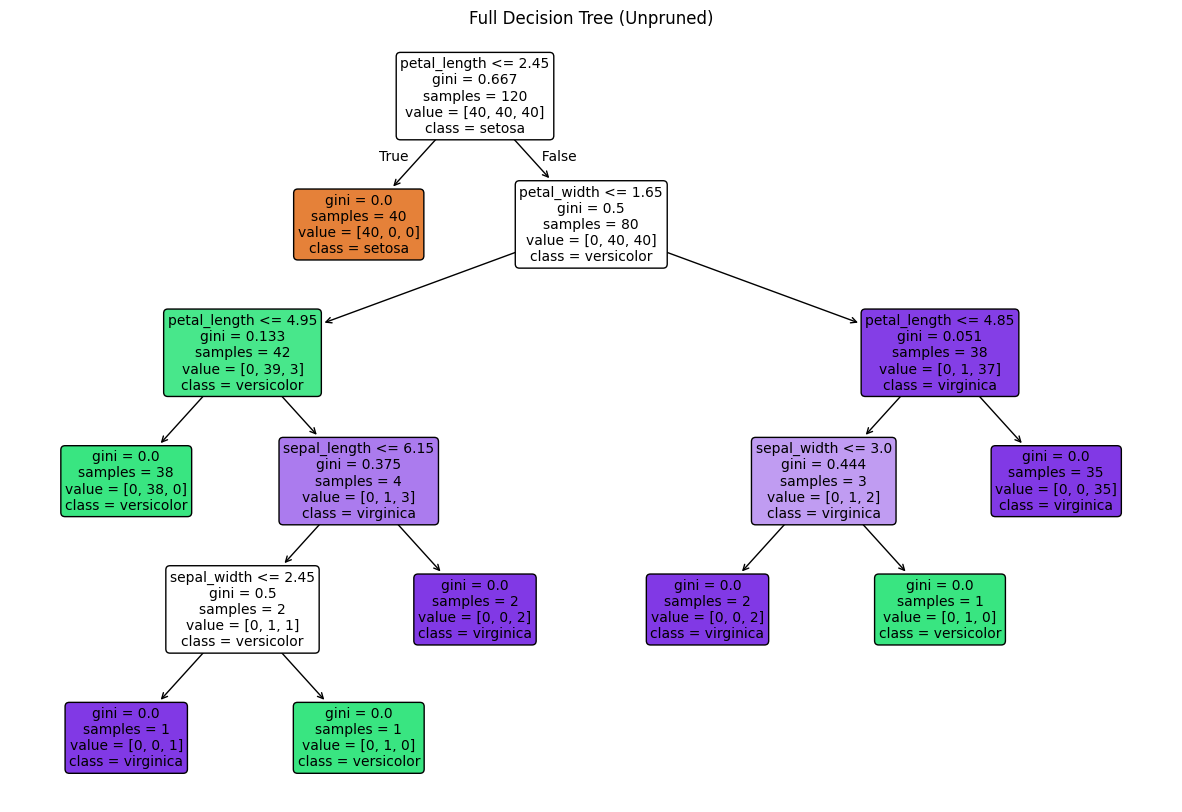


Text representation of the tree:
|--- petal_length <= 2.45
|   |--- weights: [40.00, 0.00, 0.00] class: setosa
|--- petal_length >  2.45
|   |--- petal_width <= 1.65
|   |   |--- petal_length <= 4.95
|   |   |   |--- weights: [0.00, 38.00, 0.00] class: versicolor
|   |   |--- petal_length >  4.95
|   |   |   |--- sepal_length <= 6.15
|   |   |   |   |--- sepal_width <= 2.45
|   |   |   |   |   |--- weights: [0.00, 0.00, 1.00] class: virginica
|   |   |   |   |--- sepal_width >  2.45
|   |   |   |   |   |--- weights: [0.00, 1.00, 0.00] class: versicolor
|   |   |   |--- sepal_length >  6.15
|   |   |   |   |--- weights: [0.00, 0.00, 2.00] class: virginica
|   |--- petal_width >  1.65
|   |   |--- petal_length <= 4.85
|   |   |   |--- sepal_width <= 3.00
|   |   |   |   |--- weights: [0.00, 0.00, 2.00] class: virginica
|   |   |   |--- sepal_width >  3.00
|   |   |   |   |--- weights: [0.00, 1.00, 0.00] class: versicolor
|   |   |--- petal_length >  4.85
|   |   |   |--- weights: [0.00,

In [ ]:
plt.figure(figsize=(15, 10))
plot_tree(tree,
          feature_names=X.columns,
          class_names=tree.classes_,
          filled=True,
          rounded=True,
          fontsize=10)
plt.title("Full Decision Tree (Unpruned)")
plt.show()

print("\nText representation of the tree:")
print(export_text(tree, feature_names=X.columns.tolist(), show_weights=True))

In [ ]:
pruned_tree = DecisionTreeClassifier(
    max_depth=3,
    min_samples_leaf=5,
    random_state=42
)
pruned_tree.fit(X_train, y_train)

y_pred_pruned = pruned_tree.predict(X_test)

print("Pruned Tree Performance:")
print(f"Test Accuracy : {accuracy_score(y_test, y_pred_pruned):.4f}")
print(f"Test F1-score (weighted): {f1_score(y_test, y_pred_pruned, average='weighted'):.4f}")

print("\nClassification Report (Pruned Tree):")
print(classification_report(y_test, y_pred_pruned))

Pruned Tree Performance:
Test Accuracy : 0.9333
Test F1-score (weighted): 0.9333

Classification Report (Pruned Tree):
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



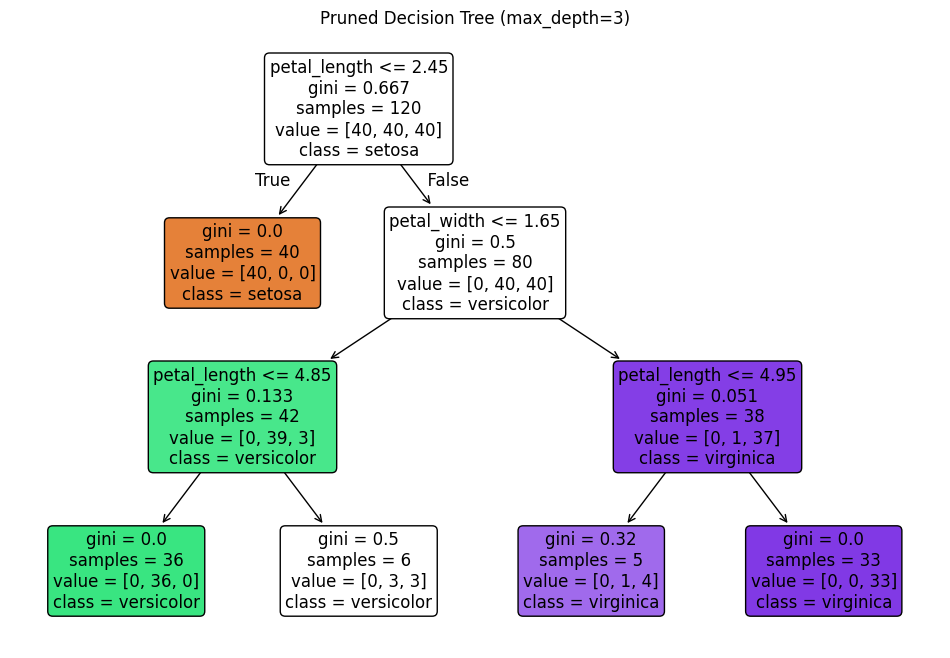

In [ ]:
plt.figure(figsize=(12, 8))
plot_tree(pruned_tree,
          feature_names=X.columns,
          class_names=pruned_tree.classes_,
          filled=True,
          rounded=True,
          fontsize=12)
plt.title("Pruned Decision Tree (max_depth=3)")
plt.show()

In [ ]:
# Level 2 Task 3 : K-Means Clustering

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

file_path = '/content/drive/MyDrive/Codveda/Churn Prdiction Data/churn-bigml-80.csv'
df = pd.read_csv(file_path)

df.columns = [col.strip() for col in df.columns]

df['International plan'] = df['International plan'].map({'Yes': 1, 'No': 0})
df['Voice mail plan']   = df['Voice mail plan'].map({'Yes': 1, 'No': 0})

features = [
    'Account length', 'Total day minutes', 'Total eve minutes',
    'Total night minutes', 'Total intl minutes', 'Customer service calls',
    'International plan', 'Voice mail plan'
]

X = df[features].copy()

print("Dataset loaded and features selected!")
print(f"Shape for clustering: {X.shape}")
print("\nFirst 5 rows of selected features:")
print(X.head())

Dataset loaded and features selected!
Shape for clustering: (2666, 8)

First 5 rows of selected features:
   Account length  Total day minutes  Total eve minutes  Total night minutes  \
0             128              265.1              197.4                244.7   
1             107              161.6              195.5                254.4   
2             137              243.4              121.2                162.6   
3              84              299.4               61.9                196.9   
4              75              166.7              148.3                186.9   

   Total intl minutes  Customer service calls  International plan  \
0                10.0                       1                   0   
1                13.7                       1                   0   
2                12.2                       0                   0   
3                 6.6                       2                   1   
4                10.1                       3                   1   

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Features scaled!")

Features scaled!


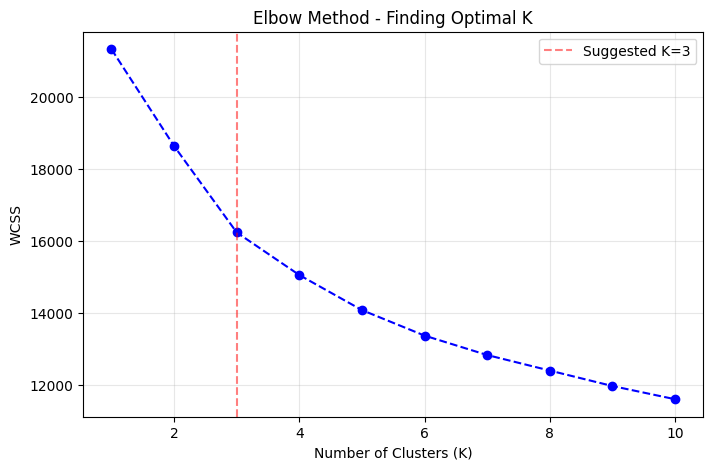

In [ ]:
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--', color='b')
plt.title('Elbow Method - Finding Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.grid(True, alpha=0.3)
plt.axvline(x=3, color='r', linestyle='--', alpha=0.5, label='Suggested K=3')
plt.legend()
plt.show()

In [ ]:
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

print(f"K-Means clustering done with K = {optimal_k}")
print("\nNumber of customers per cluster:")
print(df['Cluster'].value_counts().sort_index())

K-Means clustering done with K = 3

Number of customers per cluster:
Cluster
0     658
1    1738
2     270
Name: count, dtype: int64


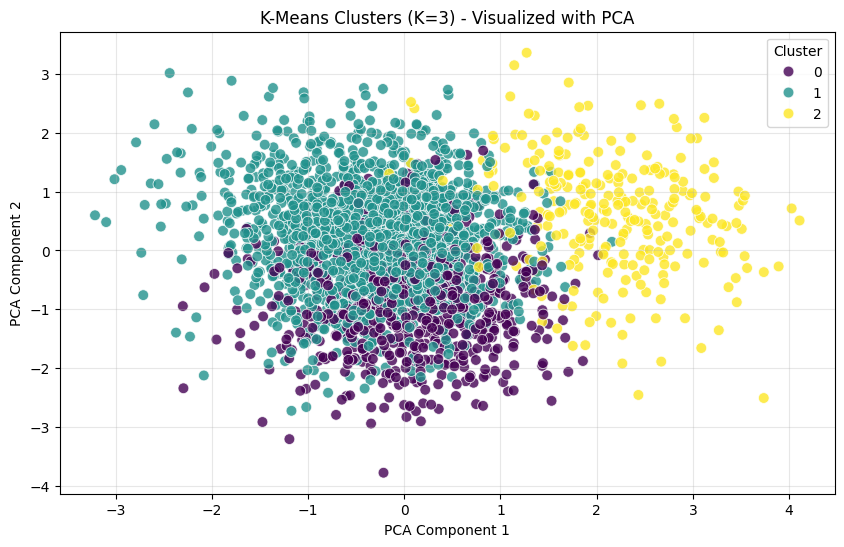

In [ ]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

df['PCA1'] = X_pca[:, 0]
df['PCA2'] = X_pca[:, 1]

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='PCA1', y='PCA2', hue='Cluster',
                palette='viridis', s=60, alpha=0.8)
plt.title(f'K-Means Clusters (K={optimal_k}) - Visualized with PCA')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend(title='Cluster')
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
cluster_profile = df.groupby('Cluster')[features].mean().round(2)
cluster_profile['Count'] = df['Cluster'].value_counts().sort_index()
cluster_profile['Percentage'] = (cluster_profile['Count'] / len(df) * 100).round(1)

print("=== Customer Segment Profiles ===")
print(cluster_profile)

print("\nAverage Churn Rate per Cluster (%):")
print(df.groupby('Cluster')['Churn'].mean().round(3) * 100)

=== Customer Segment Profiles ===
         Account length  Total day minutes  Total eve minutes  \
Cluster                                                         
0                100.53             179.56             201.77   
1                100.20             178.21             199.23   
2                103.51             187.48             204.43   

         Total night minutes  Total intl minutes  Customer service calls  \
Cluster                                                                    
0                     200.73               10.07                    1.53   
1                     201.58               10.23                    1.60   
2                     199.61               10.68                    1.42   

         International plan  Voice mail plan  Count  Percentage  
Cluster                                                          
0                       0.0             1.00    658        24.7  
1                       0.0             0.00   1738        65

In [ ]:
# Level 3 Task 1 : Build a Random Forest Classifier

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

file_path = '/content/drive/MyDrive/Codveda/Churn Prdiction Data/churn-bigml-80.csv'
df = pd.read_csv(file_path)

df.columns = [col.strip() for col in df.columns]

df['International plan'] = df['International plan'].map({'Yes': 1, 'No': 0})
df['Voice mail plan']   = df['Voice mail plan'].map({'Yes': 1, 'No': 0})

df['Churn'] = df['Churn'].map({False: 0, True: 1, 'False': 0, 'True': 1})

df = pd.get_dummies(df, columns=['State'], prefix='State', drop_first=True)

print("Preprocessing complete!")
print("Final shape:", df.shape)
print("Churn distribution:\n", df['Churn'].value_counts(normalize=True))

Preprocessing complete!
Final shape: (2666, 69)
Churn distribution:
 Churn
0    0.854464
1    0.145536
Name: proportion, dtype: float64


In [ ]:
X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples : {X_test.shape[0]}")

Training samples: 2132
Testing samples : 534


In [ ]:
rf_basic = RandomForestClassifier(n_estimators=100, random_state=42)
rf_basic.fit(X_train, y_train)

y_pred_basic = rf_basic.predict(X_test)

print("Basic Random Forest Performance:")
print(f"Accuracy : {accuracy_score(y_test, y_pred_basic):.4f}")
print(f"F1-score : {f1_score(y_test, y_pred_basic):.4f}")

Basic Random Forest Performance:
Accuracy : 0.9438
F1-score : 0.7619


In [ ]:

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 15, None],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best hyperparameters found:")
print(grid_search.best_params_)
print(f"Best cross-validation F1-score: {grid_search.best_score_:.4f}")

rf_best = grid_search.best_estimator_

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best hyperparameters found:
{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Best cross-validation F1-score: 0.7253


In [ ]:
y_pred = rf_best.predict(X_test)
y_pred_proba = rf_best.predict_proba(X_test)[:, 1]

print("Tuned Random Forest Performance on Test Set:")
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"F1-score : {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_pred_proba):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Stay (0)', 'Churn (1)']))

Tuned Random Forest Performance on Test Set:
Accuracy : 0.9438
Precision: 1.0000
Recall   : 0.6154
F1-score : 0.7619
ROC-AUC  : 0.8881

Classification Report:
              precision    recall  f1-score   support

    Stay (0)       0.94      1.00      0.97       456
   Churn (1)       1.00      0.62      0.76        78

    accuracy                           0.94       534
   macro avg       0.97      0.81      0.87       534
weighted avg       0.95      0.94      0.94       534



Top 10 Most Important Features:
                   Feature  Importance
5        Total day minutes    0.125266
7         Total day charge    0.116878
17  Customer service calls    0.107714
2       International plan    0.082525
10        Total eve charge    0.055317
8        Total eve minutes    0.051396
16       Total intl charge    0.042068
15        Total intl calls    0.039335
14      Total intl minutes    0.038817
12       Total night calls    0.037959


/tmp/ipykernel_4920/23854054.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10, x='Importance', y='Feature', palette='viridis')


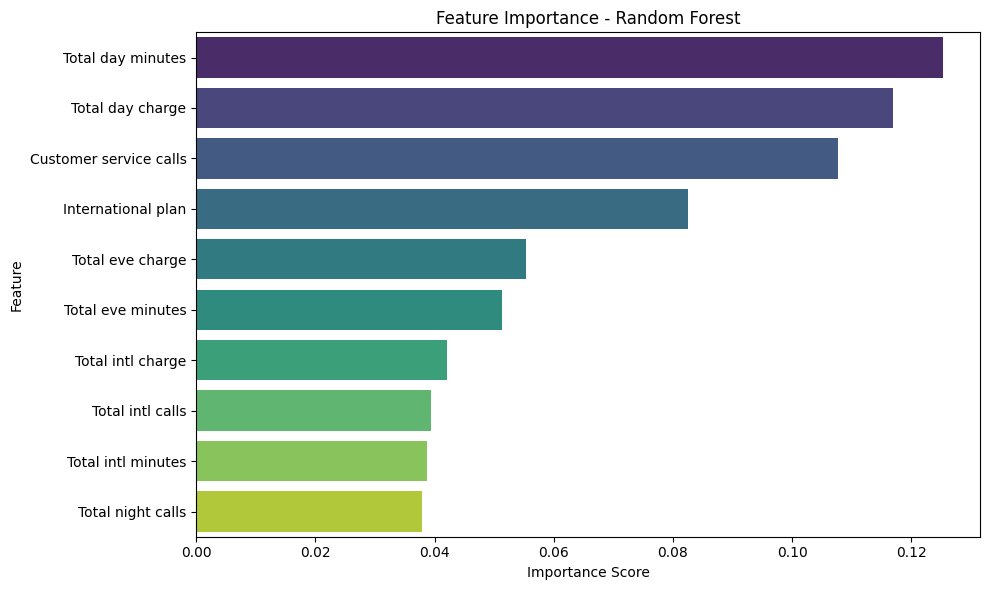

In [ ]:
importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_best.feature_importances_
}).sort_values(by='Importance', ascending=False)

top_10 = importances.head(10)

print("Top 10 Most Important Features:")
print(top_10)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_10, x='Importance', y='Feature', palette='viridis')
plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

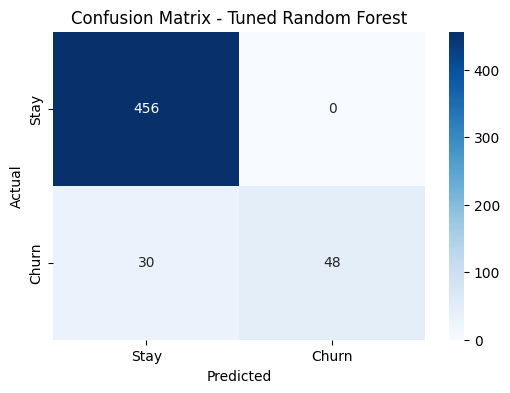

In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stay', 'Churn'],
            yticklabels=['Stay', 'Churn'])
plt.title('Confusion Matrix - Tuned Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
# Level 3 Task 2 : Support Vector Machine (SVM) for Classification

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

file_path = '/content/drive/MyDrive/Codveda/Churn Prdiction Data/churn-bigml-80.csv'
df = pd.read_csv(file_path)

df.columns = [col.strip() for col in df.columns]

df['International plan'] = df['International plan'].map({'Yes': 1, 'No': 0})
df['Voice mail plan']   = df['Voice mail plan'].map({'Yes': 1, 'No': 0})

df['Churn'] = df['Churn'].map({False: 0, True: 1, 'False': 0, 'True': 1})

df = pd.get_dummies(df, columns=['State'], prefix='State', drop_first=True)

print("Data loaded and preprocessed!")
print("Shape:", df.shape)

Data loaded and preprocessed!
Shape: (2666, 69)


In [ ]:
X = df.drop('Churn', axis=1)
y = df['Churn']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples : {X_test.shape[0]}")

Training samples: 2132
Testing samples : 534


In [ ]:
svm_linear = SVC(kernel='linear', probability=True, random_state=42)
svm_linear.fit(X_train, y_train)

print("Linear SVM trained!")

Linear SVM trained!


In [ ]:
svm_rbf = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)
svm_rbf.fit(X_train, y_train)

print("RBF SVM trained!")

RBF SVM trained!


In [ ]:
def evaluate_svm(model, name):
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    print(f"\n=== {name} Kernel Performance ===")
    print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred):.4f}")
    print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
    print(f"F1-score : {f1_score(y_test, y_pred):.4f}")
    print(f"AUC      : {roc_auc_score(y_test, y_pred_proba):.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['Stay (0)', 'Churn (1)']))

evaluate_svm(svm_linear, "Linear")
evaluate_svm(svm_rbf, "RBF")


=== Linear Kernel Performance ===
Accuracy : 0.8408
Precision: 0.3793
Recall   : 0.1410
F1-score : 0.2056
AUC      : 0.7343

Classification Report:
              precision    recall  f1-score   support

    Stay (0)       0.87      0.96      0.91       456
   Churn (1)       0.38      0.14      0.21        78

    accuracy                           0.84       534
   macro avg       0.62      0.55      0.56       534
weighted avg       0.80      0.84      0.81       534


=== RBF Kernel Performance ===
Accuracy : 0.8614
Precision: 0.6429
Recall   : 0.1154
F1-score : 0.1957
AUC      : 0.8284

Classification Report:
              precision    recall  f1-score   support

    Stay (0)       0.87      0.99      0.92       456
   Churn (1)       0.64      0.12      0.20        78

    accuracy                           0.86       534
   macro avg       0.76      0.55      0.56       534
weighted avg       0.83      0.86      0.82       534



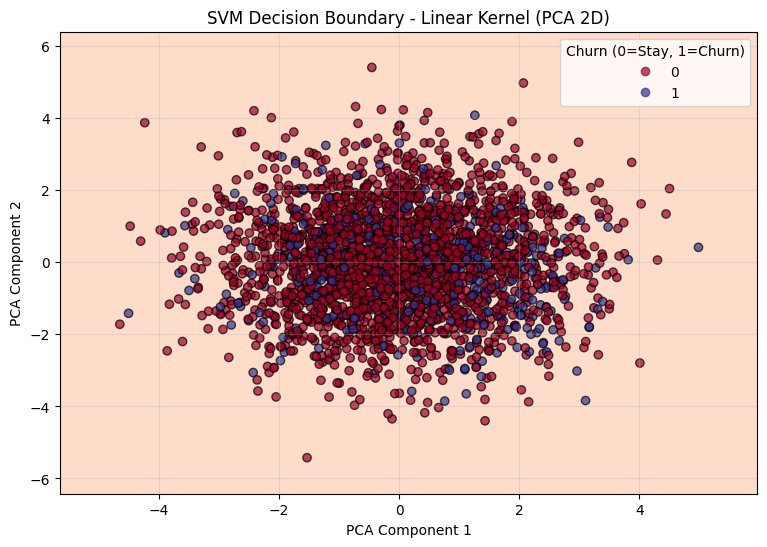

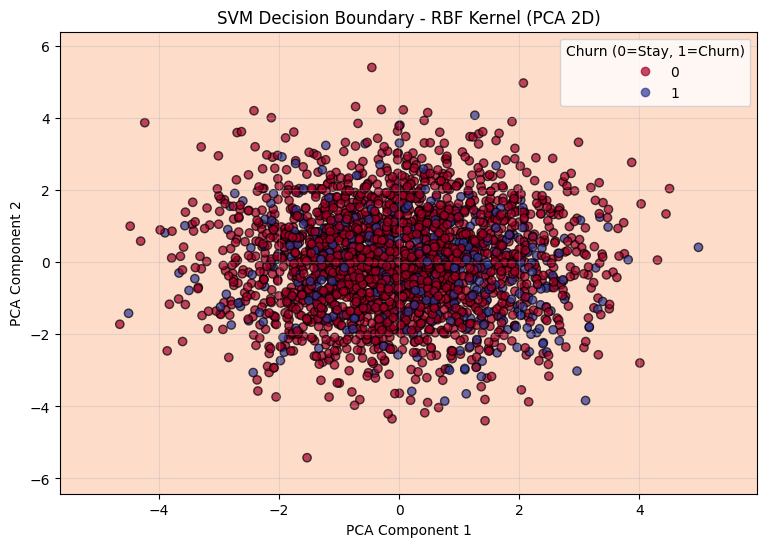

In [ ]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

svm_linear_2d = SVC(kernel='linear', probability=True, random_state=42)
svm_rbf_2d    = SVC(kernel='rbf', probability=True, random_state=42)

svm_linear_2d.fit(X_pca, y)
svm_rbf_2d.fit(X_pca, y)

def plot_decision_boundary(model, title):
    x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
    y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(9, 6))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdYlBu')
    scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='RdYlBu', edgecolor='k', alpha=0.7)
    plt.title(f'SVM Decision Boundary - {title} Kernel (PCA 2D)')
    plt.xlabel('PCA Component 1')
    plt.ylabel('PCA Component 2')
    plt.legend(*scatter.legend_elements(), title="Churn (0=Stay, 1=Churn)")
    plt.grid(True, alpha=0.3)
    plt.show()

plot_decision_boundary(svm_linear_2d, "Linear")
plot_decision_boundary(svm_rbf_2d, "RBF")

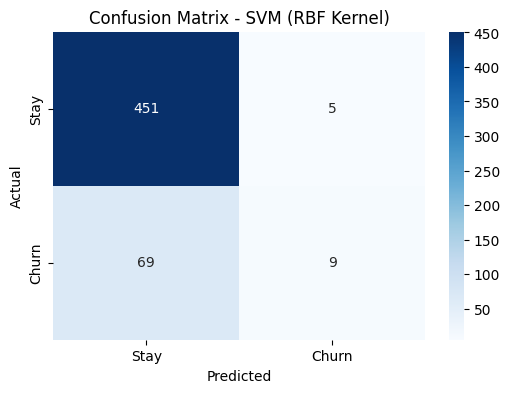

In [ ]:
y_pred_rbf = svm_rbf.predict(X_test)
cm = confusion_matrix(y_test, y_pred_rbf)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stay', 'Churn'],
            yticklabels=['Stay', 'Churn'])
plt.title('Confusion Matrix - SVM (RBF Kernel)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()